# What vocabulary size buys

A model is billed, bounded, and slowed per token, so bytes per token is a price: the fewer tokens a megabyte of text becomes, the more of it fits in a context window and the less each request costs. Vocabulary size is the one dial a tokenizer has for that, and every merge is one more entry in the model's embedding table. So: what does each doubling of vocabulary actually buy, and where does it stop?

**Design.** The tokenizer from [`01_bpe_walkthrough.ipynb`](01_bpe_walkthrough.ipynb), with GPT-2's regex pre-split, trained once on 2 MB of FineWeb-Edu prose to a 16,384 vocabulary. Merges are learned greedily and in order, so the first *k* merges of that run are exactly the tokenizer trained to *k*: one training run gives every smaller vocabulary by truncation. Bytes per token is measured at 512, 1k, 2k, 4k, 8k, and 16k on the training text and on 1 MB of held-out prose, with GPT-2 (50,257) and cl100k (100,277) measured on the same held-out text as reference points.

**Prediction, written before running.**

1. Diminishing returns: each doubling of vocabulary buys less compression than the last.
2. The held-out curve flattens before the training curve, and the gap between them opens with vocabulary size. Past a few thousand merges the tokenizer is spending vocabulary on pairs that are frequent in these 2 MB and nowhere else — a vocabulary overfits, which is why real tokenizers train on gigabytes.
3. GPT-2 at 50k lands above this run's 16k point on held-out prose, and cl100k above GPT-2 by less than its 2× vocabulary suggests — much of that vocabulary is spent on code and other languages, not English prose.

## Corpus

Two committed files from `scripts/fetch_prose.py`: the training text, and held-out documents that follow it in the same stream, so they never overlap.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import tiktoken

from tokenizer import RegexTokenizer

DATA, ASSETS = Path("../data"), Path("../assets")
MB = 1_000_000

train_text = (DATA / "prose_train.txt").read_text(encoding="utf-8")
heldout_text = (DATA / "prose_heldout.txt").read_text(encoding="utf-8")
print(f"train    {len(train_text.encode('utf-8')) / MB:.2f} MB")
print(f"held-out {len(heldout_text.encode('utf-8')) / MB:.2f} MB")

train    2.02 MB
held-out 1.01 MB


## One training run

Trained to 16k once and saved to `assets/`; loaded on later runs. The trainer recounts pair statistics from scratch every merge, over the distinct regex chunks weighted by frequency. That's the plain algorithm and it takes 10–15 minutes here — once.

In [2]:
tok, model = RegexTokenizer(), ASSETS / "prose_16k.model"
if model.exists():
    tok.load(str(model))
    print(f"loaded {len(tok.merges)} merges")
else:
    t0 = time.time()
    tok.train(train_text, vocab_size=16384, verbose=True)
    tok.save(str(ASSETS / "prose_16k"))
    print(f"trained in {(time.time() - t0) / 60:.1f} min")

merge 1000/16128: (502, 964) -> 1255 (b' control')


merge 2000/16128: (754, 322) -> 2255 (b' phot')


merge 3000/16128: (1229, 281) -> 3255 (b' clean')


merge 4000/16128: (3280, 2517) -> 4255 (b' document')


merge 5000/16128: (2933, 476) -> 5255 (b' satell')


...

merge 13000/16128: (7611, 615) -> 13255 (b' diminish')


merge 14000/16128: (14254, 1878) -> 14255 (b' Oracle')


merge 15000/16128: (7926, 273) -> 15255 (b'visor')


merge 16000/16128: (919, 13738) -> 16255 (b' myprogram')


trained in 6.5 min


## The sweep

Truncation, not retraining: `tok.truncated(v)` keeps the first `v - 256` merges, which is the tokenizer that training to `v` would have produced.

In [3]:
def bytes_per_token(encode, text):
    return len(text.encode("utf-8")) / len(encode(text))

sizes = [512, 1024, 2048, 4096, 8192, 16384]
train_bpt, heldout_bpt = {}, {}
for v in sizes:
    t = tok.truncated(v)
    train_bpt[v], heldout_bpt[v] = bytes_per_token(t.encode, train_text), bytes_per_token(t.encode, heldout_text)

gpt2, cl100k = tiktoken.get_encoding("gpt2"), tiktoken.get_encoding("cl100k_base")
refs = {"gpt2": (gpt2.n_vocab, bytes_per_token(gpt2.encode_ordinary, heldout_text)),
        "cl100k": (cl100k.n_vocab, bytes_per_token(cl100k.encode_ordinary, heldout_text))}

print(f"{'vocab':>8s}{'train':>9s}{'held-out':>10s}{'gap':>7s}")
for v in sizes:
    print(f"{v:8d}{train_bpt[v]:9.3f}{heldout_bpt[v]:10.3f}{100 * (train_bpt[v] / heldout_bpt[v] - 1):6.1f}%")
for name, (n, bpt) in refs.items():
    print(f"{name:>8s}{'':9s}{bpt:10.3f}   ({n:,} vocab)")

   vocab    train  held-out    gap
     512    2.013     2.013  -0.0%
    1024    2.509     2.505   0.1%
    2048    2.975     2.949   0.9%
    4096    3.472     3.402   2.0%
    8192    3.979     3.833   3.8%
   16384    4.440     4.197   5.8%
    gpt2              4.657   (50,257 vocab)
  cl100k              4.779   (100,277 vocab)


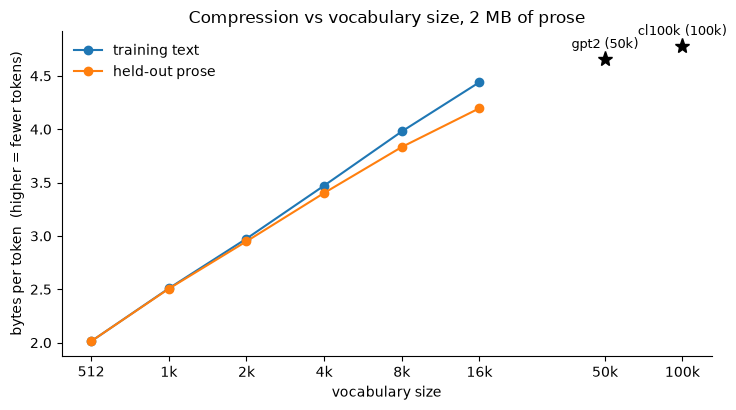

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sizes, [train_bpt[v] for v in sizes], "o-", label="training text")
ax.plot(sizes, [heldout_bpt[v] for v in sizes], "o-", label="held-out prose")
for name, (n, bpt) in refs.items():
    ax.plot([n], [bpt], "k*", markersize=11)
    ax.annotate(f"{name} ({n // 1000}k)", (n, bpt), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xscale("log", base=2)
ax.set_xticks(sizes + [refs["gpt2"][0], refs["cl100k"][0]])
ax.set_xticklabels([f"{v // 1024}k" if v >= 1024 else str(v) for v in sizes] + ["50k", "100k"])
ax.set_xlabel("vocabulary size")
ax.set_ylabel("bytes per token  (higher = fewer tokens)")
ax.set_title("Compression vs vocabulary size, 2 MB of prose")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "vocab_size.png", dpi=150)

## What each doubling buys, and what a window holds

The same numbers read two ways: the marginal gain per doubling, and how much prose fits in a fixed context — 256 tokens is the [gpt](https://github.com/diego-magana/gpt) repo's block size, 1,024 is GPT-2's.

In [5]:
print(f"{'doubling':>14s}{'held-out gain':>15s}")
for a, b in zip(sizes, sizes[1:]):
    print(f"{a:>6d} -> {b:<5d}{100 * (heldout_bpt[b] / heldout_bpt[a] - 1):+13.1f}%")

print(f"\n{'vocab':>8s}{'bytes / 256 tokens':>20s}{'bytes / 1024 tokens':>21s}")
for v in sizes:
    print(f"{v:8d}{256 * heldout_bpt[v]:20,.0f}{1024 * heldout_bpt[v]:21,.0f}")
for name, (n, bpt) in refs.items():
    print(f"{name:>8s}{256 * bpt:20,.0f}{1024 * bpt:21,.0f}")

      doubling  held-out gain
   512 -> 1024         +24.5%
  1024 -> 2048         +17.7%
  2048 -> 4096         +15.4%
  4096 -> 8192         +12.7%
  8192 -> 16384         +9.5%

   vocab  bytes / 256 tokens  bytes / 1024 tokens
     512                 515                2,061
    1024                 641                2,566
    2048                 755                3,020
    4096                 871                3,484
    8192                 981                3,925
   16384               1,074                4,297
    gpt2               1,192                4,769
  cl100k               1,223                4,894


## README block

Generated from the results above so the README can't drift from the notebook.

In [6]:
lines = ["| vocab | train | held-out | gap | bytes per 1,024-token window |", "|---|---|---|---|---|"]
for v in sizes:
    lines.append(f"| {v:,} | {train_bpt[v]:.2f} | {heldout_bpt[v]:.2f} | {100 * (train_bpt[v] / heldout_bpt[v] - 1):.1f}% | {1024 * heldout_bpt[v]:,.0f} |")
for name, (n, bpt) in refs.items():
    lines.append(f"| {name} ({n:,}) | — | {bpt:.2f} | — | {1024 * bpt:,.0f} |")
print("\n".join(lines))
print()
first, last = sizes[0], sizes[-1]
print(f"The first doubling (512 → 1k) buys {100 * (heldout_bpt[1024] / heldout_bpt[512] - 1):+.0f}% on held-out prose; "
      f"the last (8k → 16k) buys {100 * (heldout_bpt[16384] / heldout_bpt[8192] - 1):+.0f}%. "
      f"The train/held-out gap goes from {100 * (train_bpt[first] / heldout_bpt[first] - 1):.1f}% at 512 "
      f"to {100 * (train_bpt[last] / heldout_bpt[last] - 1):.1f}% at 16k. "
      f"On the same held-out prose GPT-2 reaches {refs['gpt2'][1]:.2f} bytes per token and cl100k {refs['cl100k'][1]:.2f}, "
      f"against {heldout_bpt[last]:.2f} at 16k here. "
      f"A 1,024-token window holds {1024 * heldout_bpt[first]:,.0f} bytes of prose at 512 vocabulary, "
      f"{1024 * heldout_bpt[last]:,.0f} at 16k, and {1024 * refs['gpt2'][1]:,.0f} under GPT-2.")

| vocab | train | held-out | gap | bytes per 1,024-token window |
|---|---|---|---|---|
| 512 | 2.01 | 2.01 | -0.0% | 2,061 |
| 1,024 | 2.51 | 2.51 | 0.1% | 2,566 |
| 2,048 | 2.97 | 2.95 | 0.9% | 3,020 |
| 4,096 | 3.47 | 3.40 | 2.0% | 3,484 |
| 8,192 | 3.98 | 3.83 | 3.8% | 3,925 |
| 16,384 | 4.44 | 4.20 | 5.8% | 4,297 |
| gpt2 (50,257) | — | 4.66 | — | 4,769 |
| cl100k (100,277) | — | 4.78 | — | 4,894 |

The first doubling (512 → 1k) buys +24% on held-out prose; the last (8k → 16k) buys +9%. The train/held-out gap goes from -0.0% at 512 to 5.8% at 16k. On the same held-out prose GPT-2 reaches 4.66 bytes per token and cl100k 4.78, against 4.20 at 16k here. A 1,024-token window holds 2,061 bytes of prose at 512 vocabulary, 4,297 at 16k, and 4,769 under GPT-2.


## What this shows

All three predictions held. Each doubling bought less than the last on held-out prose — +24% for the first, +9% for the last — and the train/held-out gap opened from 0.0% at 512 to 5.8% at 16k: past a few thousand merges the vocabulary is increasingly spent on pairs particular to these 2 MB. GPT-2 reaches 4.66 bytes per token on the same held-out text, 11% above this run's 16k point with three times the vocabulary, and cl100k adds only 2.6% more with twice the vocabulary again; the rest of its 100k is spent on code and other languages. The held-out curve, continued at its declining rate, passes close to GPT-2's point at 50k — an extrapolation, but a suggestive one about how little of a production vocabulary is needed for English prose.

## What this doesn't show

- **Compression, not quality.** Bytes per token says what text costs, not how well a model trained on those tokens predicts it. Whether a larger vocabulary helps a model is a training experiment, not a tokenizer one.
- **One corpus, and a small one.** Two megabytes of English prose is what makes the held-out gap visible; it is also why the absolute numbers are below GPT-2's. The shape of the curve is the result, not its height.
- **The references are not on the curve.** GPT-2 and cl100k were trained on other corpora and, for cl100k, a different pre-split regex. They show where production tokenizers land on this text, not what this trainer would reach at their size.